# dh_tool.dataframe 사용 예시

이 노트북은 dh_tool.dataframe 패키지의 주요 기능을 보여주는 예시들을 포함하고 있습니다.

In [1]:
import pandas as pd
import numpy as np
from dh_tool.dataframe import Sheets, DataFrame

## 1. 데이터 생성 및 기본 조작

In [2]:
# 샘플 데이터 생성
data = pd.DataFrame({
    'A': np.random.rand(100),
    'B': np.random.randint(0, 100, 100),
    'C': ['cat', 'dog', 'bird'] * 33 + ['cat']
})

# Sheets 객체 생성
sheets = Sheets(data)
sheets.df.head()

,A,B,C
0,0.957748,73,cat
1,0.911362,48,dog
2,0.503416,33,bird
3,0.280192,47,cat
4,0.272616,21,dog


## 2. 데이터 필터링

In [3]:
# 'B' 열의 값이 50 이상인 행만 필터링
filtered = sheets.select_rows(include={'B': (">", 50)})
filtered.head()

,A,B,C
0,0.957748,73,cat
5,0.072763,74,bird
7,0.228705,74,dog
8,0.257568,89,bird
9,0.698436,53,cat


## 3. 그룹화 및 집계

In [4]:
# 'C' 열로 그룹화하고 'A'와 'B' 열의 평균 계산
grouped = sheets.group_and_aggregate('C', A='mean', B='max')
grouped

,A,B
C,,
bird,0.517927,91
cat,0.543643,91
dog,0.505351,99


## 4. 시각화

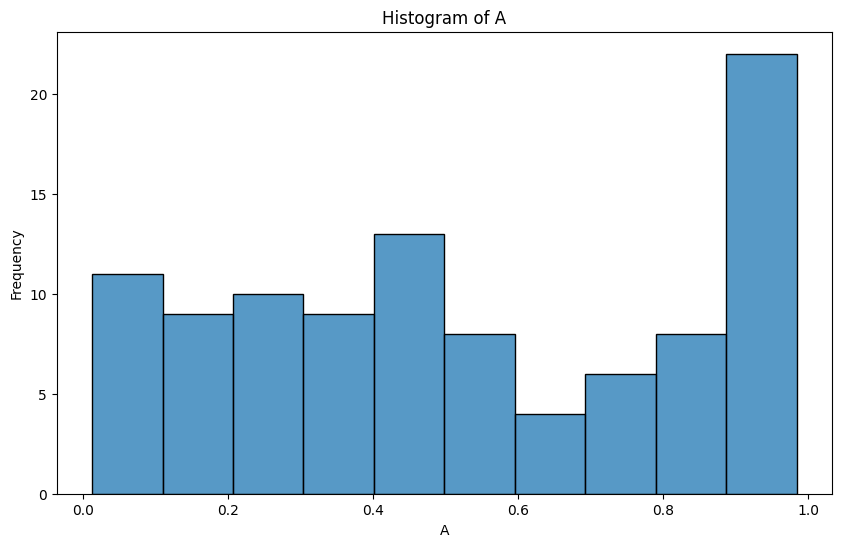

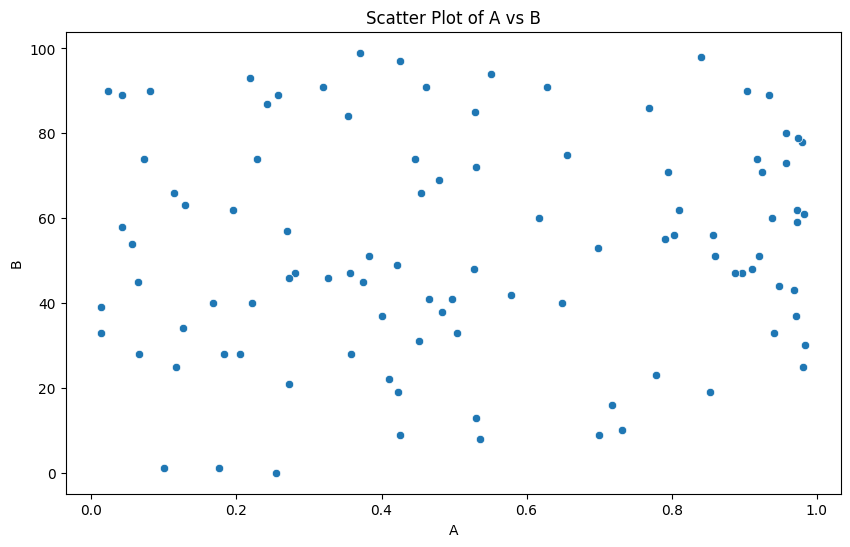

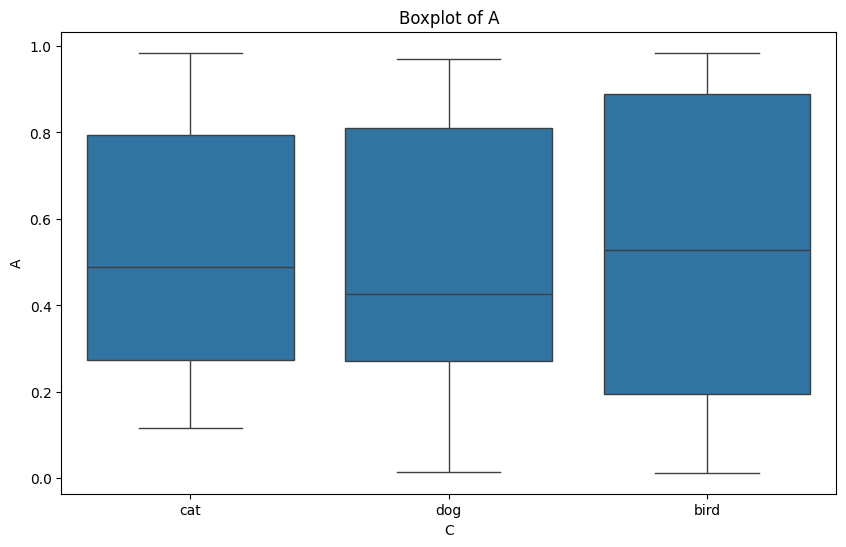

In [5]:
# 히스토그램 그리기
sheets.plot_histogram('A')

# 산점도 그리기
sheets.plot_scatter('A', 'B')

# 박스플롯 그리기
sheets.plot_boxplot('A', by='C')

## 5. Excel 관련 기능

In [6]:
# 새 시트 생성
new_data = pd.DataFrame({'X': range(10), 'Y': range(10, 20)})
sheets.create_sheet(new_data, 'NewSheet')

# 열 너비 설정
sheets.set_column_width(X=15, Y=20)

# 첫 번째 행 고정
sheets.freeze_first_row()

# 엑셀 파일로 저장
sheets.save('example.xlsx')

print("Excel file 'example.xlsx' has been created.")

Excel file 'example.xlsx' has been created.


In [7]:
sheets.select_sheet('Sheet1')

## 6. 고급 기능

In [8]:

# 사용자 정의 함수 적용
def custom_function(x):
    return x * 2 if isinstance(x, (int, float)) else x

result = sheets.apply_function(custom_function)
result.head()

# 피벗 테이블 생성
pivot = sheets.df_handler.pivot_table(values='A', index='C', columns='B', aggfunc='mean')
pivot.head()

# 데이터 정규화
normalized = sheets.normalize(columns=['A', 'B'])
normalized.head()

,A,B,C
0,0.972541,0.737374,cat
1,0.924787,0.484848,dog
2,0.504804,0.333333,bird
3,0.274993,0.474747,cat
4,0.267194,0.212121,dog


In [9]:
sheets.sheet_names

['Sheet1', 'NewSheet']

In [12]:
sheets.select_sheet("NewSheet")

In [13]:
sheets

,X,Y
0,0,10
1,1,11
2,2,12
3,3,13
4,4,14
5,5,15
6,6,16
7,7,17
8,8,18
9,9,19
